# FootballAnalysisML: End-to-End Notebook

This notebook is the main Jupyter Lab workflow for the project.

Run it from top to bottom, cell by cell, to:
- explore the FIFA 18 dataset with the same style of graphs as the old notebook
- build deterministic role and exact-position targets
- train the improved models
- inspect metrics, confusion matrices, and saved artifacts


In [1]:
%matplotlib inline

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'football_analysis').exists() and (candidate / 'FootballAnalysisML').exists():
            return candidate
    raise RuntimeError('Could not find the project root from the current notebook location.')


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print(f'Project root: {PROJECT_ROOT}')


Project root: D:\coding\FootballAnalysisML


In [2]:
from football_analysis.data import DEFAULT_DATA_PATH, add_targets, build_model_frame, load_raw_data
from football_analysis.legacy import compute_legacy_role_baseline
from football_analysis.reporting import evaluate_saved_model
from football_analysis.train_position import train_position_model
from football_analysis.train_role import train_role_model

ARTIFACTS_DIR = PROJECT_ROOT / 'artifacts' / 'notebook'
ROLE_ARTIFACTS_DIR = ARTIFACTS_DIR / 'role'
POSITION_ARTIFACTS_DIR = ARTIFACTS_DIR / 'position'

data = load_raw_data(DEFAULT_DATA_PATH)
prepared = add_targets(data)

print(f'Dataset path: {DEFAULT_DATA_PATH}')
print(f'Shape: {data.shape}')
display(prepared[['short_name', 'player_positions', 'primary_position', 'role_target', 'position_target']].head(10))


Dataset path: D:\coding\FootballAnalysisML\FootballAnalysisML\players_18.csv
Shape: (17954, 110)


,short_name,player_positions,primary_position,role_target,position_target
0,Cristiano Ronaldo,"LW, ST",LW,attack,LW
1,L. Messi,RW,RW,attack,RW
2,M. Neuer,GK,GK,goalkeeper,GK
3,L. Suárez,ST,ST,attack,ST
4,Neymar,LW,LW,attack,LW
5,R. Lewandowski,ST,ST,attack,ST
6,Sergio Ramos,CB,CB,defense,CB
7,G. Higuaín,ST,ST,attack,ST
8,T. Kroos,"CM, CDM",CM,midfield,CM
9,E. Hazard,LW,LW,attack,LW


## Data exploration

These graphs are intentionally similar to the old notebook: correlation heatmap, line plot, bar plot, box plot, and position distribution.

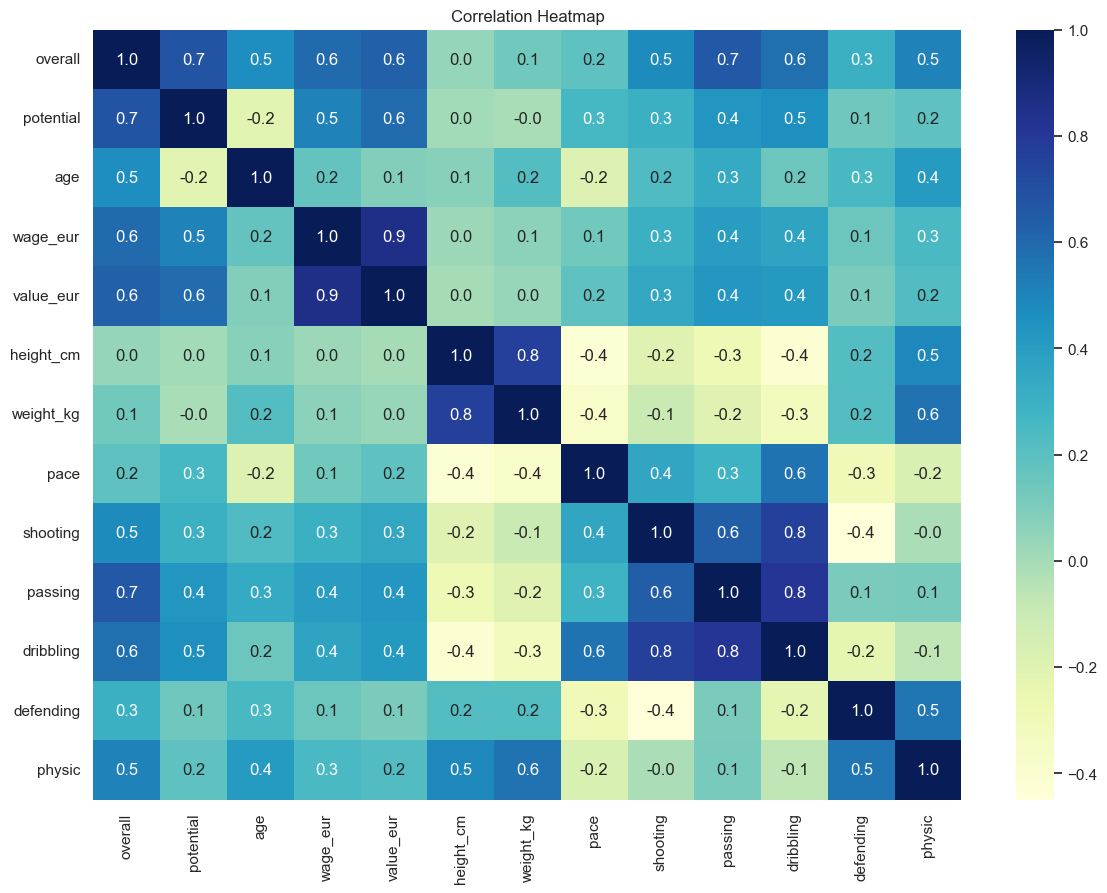

In [3]:
# Heatmap visualization of selected column correlations
correlation_cols = [
    'overall', 'potential', 'age', 'wage_eur', 'value_eur', 'height_cm', 'weight_kg',
    'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic'
]

correlation = data[correlation_cols].corr(numeric_only=True)
plt.figure(figsize=(14, 10))
sns.heatmap(data=correlation, annot=True, fmt='.1f', cmap='YlGnBu')
plt.title('Correlation Heatmap')
plt.show()


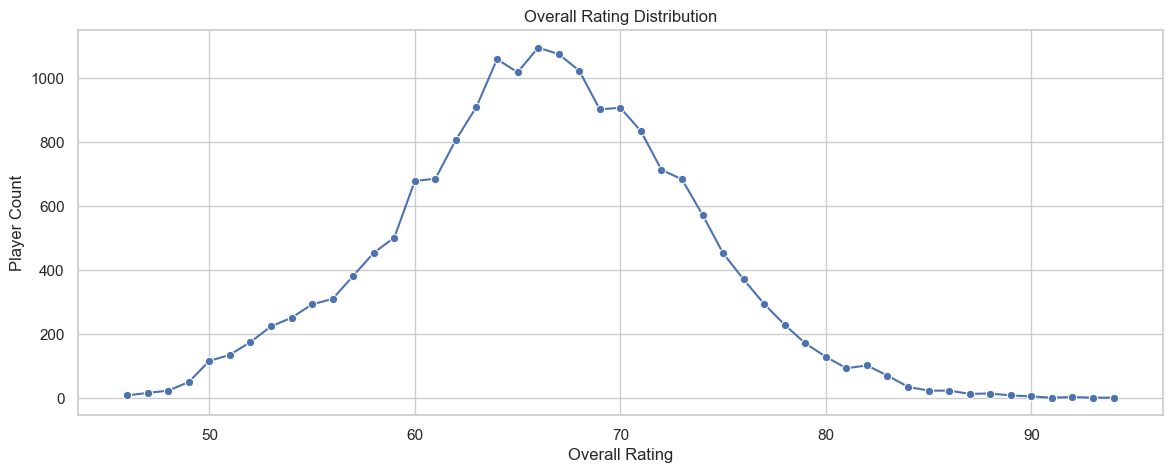

In [4]:
# Distribution of overall ratings
overall_counts = (
    data['overall']
    .value_counts(normalize=False)
    .sort_index()
    .reset_index()
)
overall_counts.columns = ['overall_rating', 'player_count']

plt.figure(figsize=(14, 5))
sns.lineplot(data=overall_counts, x='overall_rating', y='player_count', marker='o')
plt.title('Overall Rating Distribution')
plt.xlabel('Overall Rating')
plt.ylabel('Player Count')
plt.show()


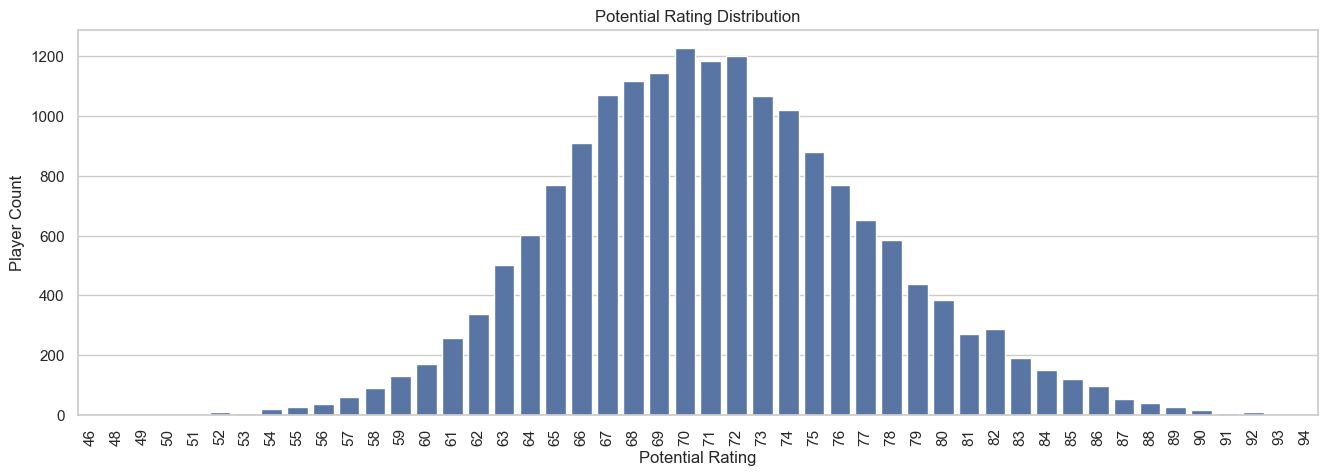

In [5]:
# Distribution of potential ratings
potential_counts = (
    data['potential']
    .value_counts(normalize=False)
    .sort_index()
    .reset_index()
)
potential_counts.columns = ['potential_rating', 'player_count']

plt.figure(figsize=(16, 5))
sns.barplot(data=potential_counts, x='potential_rating', y='player_count', color='#4C72B0')
plt.title('Potential Rating Distribution')
plt.xlabel('Potential Rating')
plt.ylabel('Player Count')
plt.xticks(rotation=90)
plt.show()


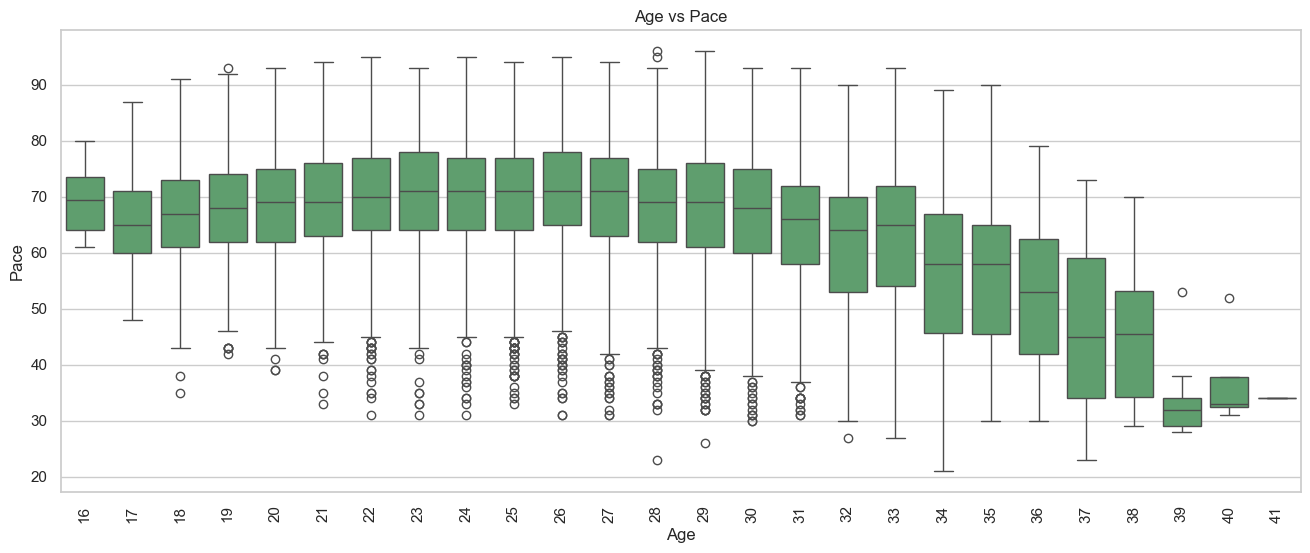

In [6]:
# Relation between age and pace
pace_by_age = data[['age', 'pace']].dropna().copy()
plt.figure(figsize=(16, 6))
sns.boxplot(data=pace_by_age, x='age', y='pace', color='#55A868')
plt.title('Age vs Pace')
plt.xlabel('Age')
plt.ylabel('Pace')
plt.xticks(rotation=90)
plt.show()


In [7]:
# Stats of players
country = 'Egypt'
player_count = len(data.loc[data['nationality_name'] == country])
average_wage = float(data['wage_eur'].mean())
players_above_average_wage = len(data.loc[data['wage_eur'] > average_wage])
percentage_above_average = (players_above_average_wage / len(data)) * 100

print(f"There's {player_count} players from {country}.")
print(f'The average wage is {average_wage:.1f} euro.')
print(f'The percentage of players with more than average wage is {percentage_above_average:.1f}%.')


There's 31 players from Egypt.
The average wage is 11393.0 euro.
The percentage of players with more than average wage is 22.4%.


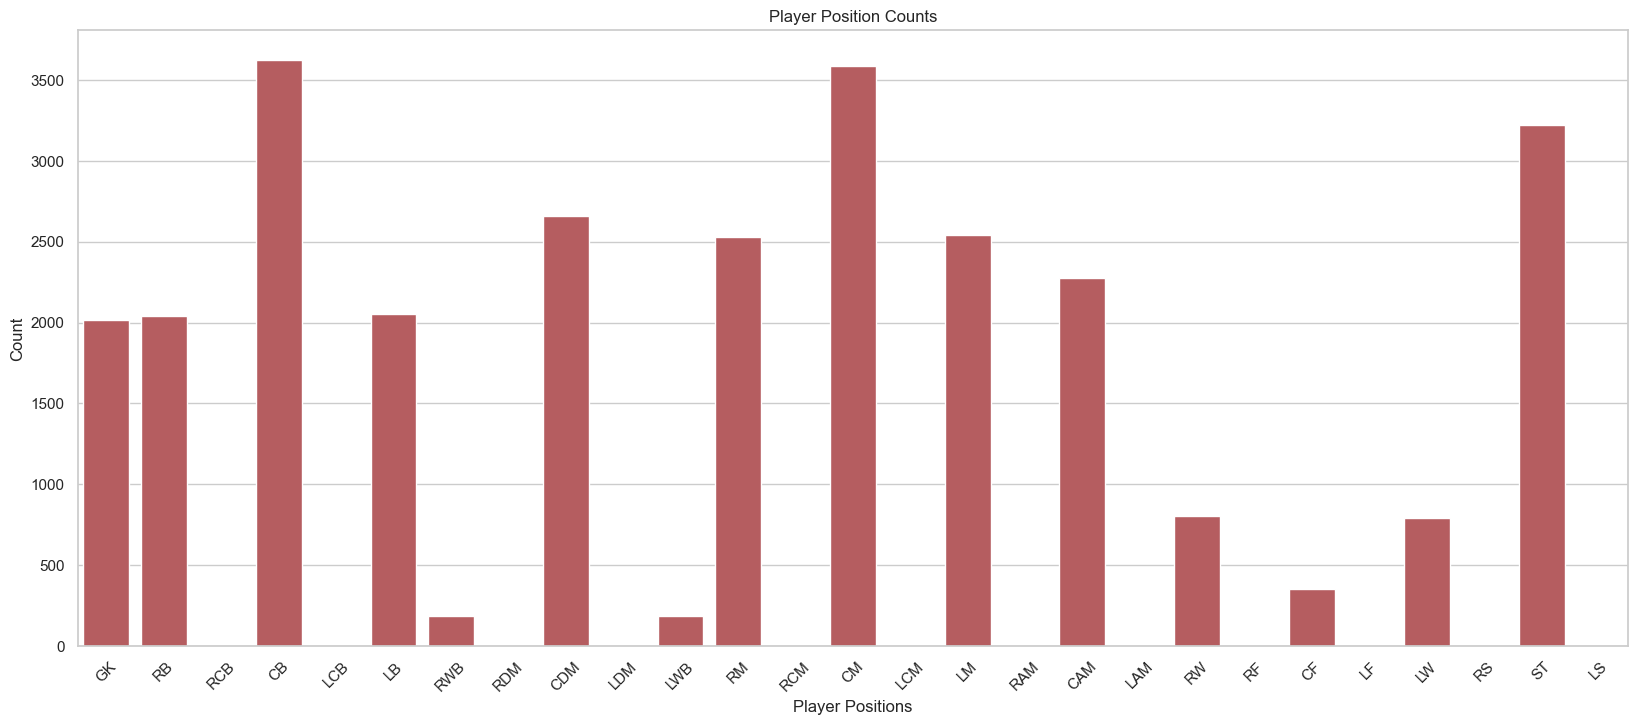

In [8]:
# Most chosen player positions
positions = [
    'GK', 'RB', 'RCB', 'CB', 'LCB', 'LB', 'RWB', 'RDM', 'CDM', 'LDM', 'LWB',
    'RM', 'RCM', 'CM', 'LCM', 'LM', 'RAM', 'CAM', 'LAM', 'RW', 'RF', 'CF',
    'LF', 'LW', 'RS', 'ST', 'LS'
]

position_counts = prepared['player_positions'].str.split(', ').explode().value_counts()
position_counts = position_counts.reindex(positions, fill_value=0)

plt.figure(figsize=(20, 8))
sns.barplot(x=position_counts.index, y=position_counts.values, color='#C44E52')
plt.title('Player Position Counts')
plt.xlabel('Player Positions')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()


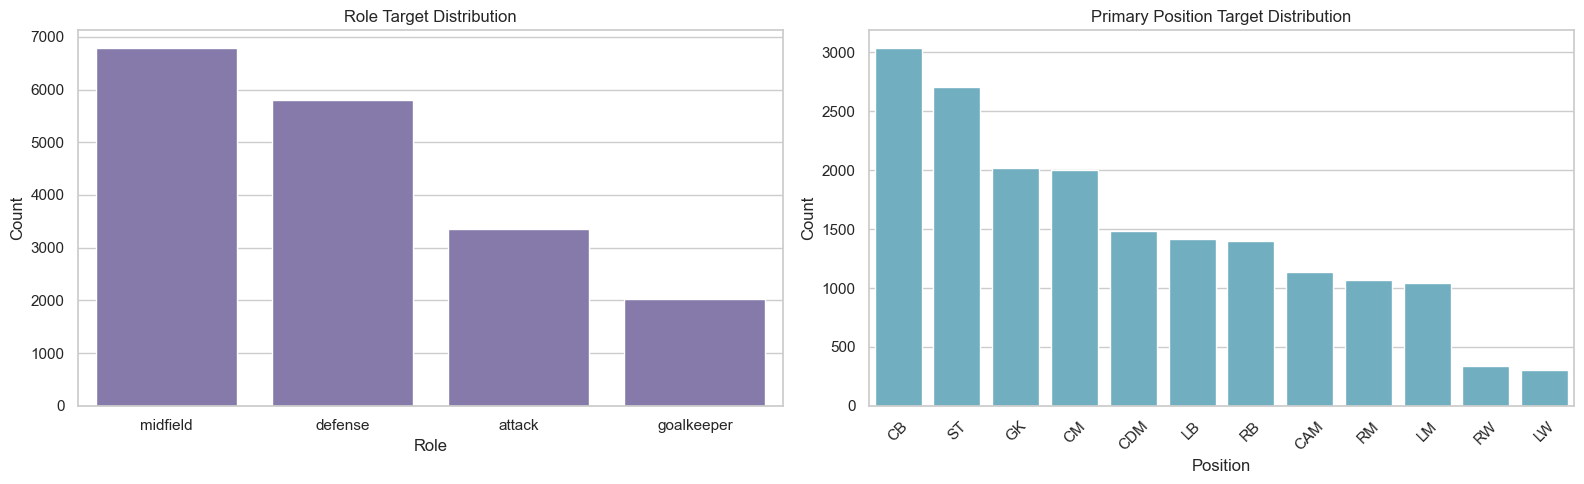

In [9]:
# Deterministic target distributions used by the new pipeline
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

role_counts = prepared['role_target'].value_counts().sort_values(ascending=False)
sns.barplot(x=role_counts.index, y=role_counts.values, ax=axes[0], color='#8172B2')
axes[0].set_title('Role Target Distribution')
axes[0].set_xlabel('Role')
axes[0].set_ylabel('Count')

position_counts_new = prepared['position_target'].value_counts().sort_values(ascending=False)
sns.barplot(x=position_counts_new.index, y=position_counts_new.values, ax=axes[1], color='#64B5CD')
axes[1].set_title('Primary Position Target Distribution')
axes[1].set_xlabel('Position')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


## Role model training

This trains the improved `attack` / `midfield` / `defense` / `goalkeeper` classifier directly from the raw CSV.

In [10]:
ROLE_SEARCH_ITERATIONS = 3
ROLE_CV_FOLDS = 5
ROLE_RANDOM_STATE = 15

legacy_baseline = compute_legacy_role_baseline(random_state=ROLE_RANDOM_STATE)
legacy_baseline


{'accuracy': 0.6507936507936508, 'macro_f1': 0.6980870085543748}

In [11]:
role_result = train_role_model(
    output_dir=ROLE_ARTIFACTS_DIR,
    random_state=ROLE_RANDOM_STATE,
    search_iterations=ROLE_SEARCH_ITERATIONS,
    cv_folds=ROLE_CV_FOLDS,
    compute_legacy_baseline=True,
)
role_result['metrics']


{'accuracy': 0.9000278473962684,
 'macro_f1': 0.9124335839916814,
 'weighted_f1': 0.8997505571218414,
 'labels': ['attack', 'defense', 'goalkeeper', 'midfield'],
 'classification_report': {'attack': {'precision': 0.8509687034277198,
   'recall': 0.8535127055306427,
   'f1-score': 0.8522388059701492,
   'support': 669.0},
  'defense': {'precision': 0.9178541492036881,
   'recall': 0.9431524547803618,
   'f1-score': 0.9303313508920985,
   'support': 1161.0},
  'goalkeeper': {'precision': 1.0,
   'recall': 1.0,
   'f1-score': 1.0,
   'support': 404.0},
  'midfield': {'precision': 0.8783068783068783,
   'recall': 0.8563006632277081,
   'f1-score': 0.8671641791044776,
   'support': 1357.0},
  'accuracy': 0.9000278473962684,
  'macro avg': {'precision': 0.9117824327345715,
   'recall': 0.9132414558846782,
   'f1-score': 0.9124335839916814,
   'support': 3591.0},
  'weighted avg': {'precision': 0.8996906610083709,
   'recall': 0.9000278473962684,
   'f1-score': 0.8997505571218414,
   'support

In [12]:
role_metrics = json.loads((ROLE_ARTIFACTS_DIR / 'metrics.json').read_text(encoding='utf-8'))
role_report = pd.DataFrame(role_metrics['classification_report']).T
display(role_report)

print(f"Role accuracy: {role_metrics['accuracy']:.4f}")
print(f"Role macro F1: {role_metrics['macro_f1']:.4f}")
print(f"Best model: {role_metrics['best_model_name']}")
print(f"Best params: {role_metrics['best_params']}")


,precision,recall,f1-score,support
attack,0.850969,0.853513,0.852239,669.000000
defense,0.917854,0.943152,0.930331,1161.000000
goalkeeper,1.000000,1.000000,1.000000,404.000000
midfield,0.878307,0.856301,0.867164,1357.000000
accuracy,0.900028,0.900028,0.900028,0.900028
macro avg,0.911782,0.913241,0.912434,3591.000000
weighted avg,0.899691,0.900028,0.899751,3591.000000


Role accuracy: 0.9000
Role macro F1: 0.9124
Best model: extra_trees
Best params: {'model__n_estimators': 300, 'model__min_samples_split': 10, 'model__min_samples_leaf': 4, 'model__max_features': 0.5, 'model__max_depth': 15, 'model__class_weight': 'balanced'}


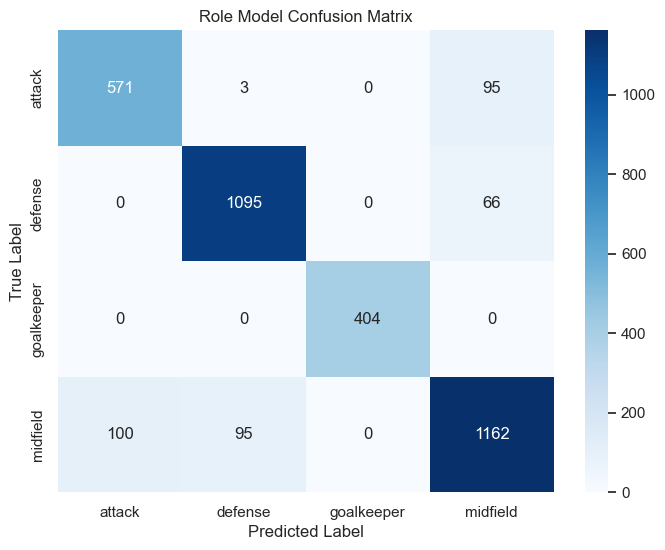

In [13]:
role_labels = role_metrics['labels']
role_confusion = pd.DataFrame(
    role_metrics['confusion_matrix'],
    index=role_labels,
    columns=role_labels,
)

plt.figure(figsize=(8, 6))
sns.heatmap(role_confusion, annot=True, fmt='d', cmap='Blues')
plt.title('Role Model Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


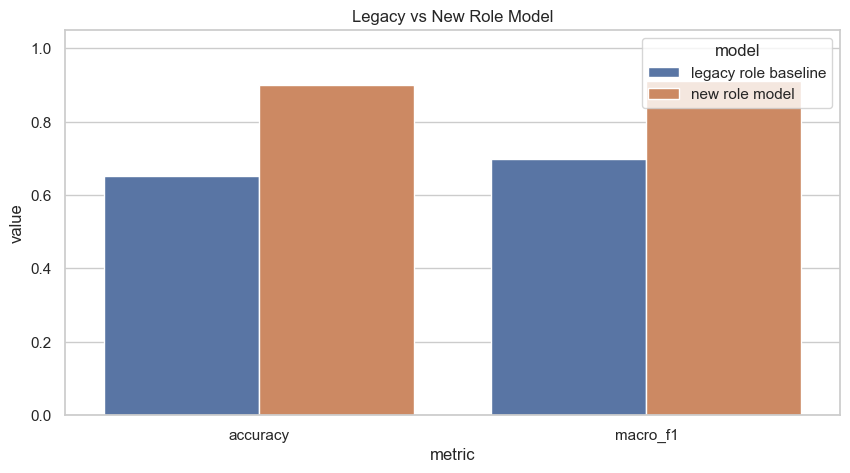

In [14]:
comparison = pd.DataFrame([
    {'model': 'legacy role baseline', 'metric': 'accuracy', 'value': role_metrics['legacy_baseline']['accuracy']},
    {'model': 'legacy role baseline', 'metric': 'macro_f1', 'value': role_metrics['legacy_baseline']['macro_f1']},
    {'model': 'new role model', 'metric': 'accuracy', 'value': role_metrics['accuracy']},
    {'model': 'new role model', 'metric': 'macro_f1', 'value': role_metrics['macro_f1']},
])

plt.figure(figsize=(10, 5))
sns.barplot(data=comparison, x='metric', y='value', hue='model')
plt.title('Legacy vs New Role Model')
plt.ylim(0, 1.05)
plt.show()


## Exact-position model training

This trains the merged exact-position classifier from the same raw CSV.

In [15]:
POSITION_SEARCH_ITERATIONS = 3
POSITION_CV_FOLDS = 5
POSITION_RANDOM_STATE = 15

position_result = train_position_model(
    output_dir=POSITION_ARTIFACTS_DIR,
    random_state=POSITION_RANDOM_STATE,
    search_iterations=POSITION_SEARCH_ITERATIONS,
    cv_folds=POSITION_CV_FOLDS,
)
position_result['metrics']


{'accuracy': 0.7371205792258424,
 'macro_f1': 0.6102630817499786,
 'weighted_f1': 0.7325775802596994,
 'labels': ['CAM',
  'CB',
  'CDM',
  'CM',
  'GK',
  'LB',
  'LM',
  'LW',
  'RB',
  'RM',
  'RW',
  'ST'],
 'classification_report': {'CAM': {'precision': 0.4942084942084942,
   'recall': 0.5614035087719298,
   'f1-score': 0.5256673511293635,
   'support': 228.0},
  'CB': {'precision': 0.9388489208633094,
   'recall': 0.8599670510708401,
   'f1-score': 0.8976784178847808,
   'support': 607.0},
  'CDM': {'precision': 0.6166134185303515,
   'recall': 0.652027027027027,
   'f1-score': 0.6338259441707718,
   'support': 296.0},
  'CM': {'precision': 0.6492537313432836,
   'recall': 0.6508728179551122,
   'f1-score': 0.6500622665006227,
   'support': 401.0},
  'GK': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 404.0},
  'LB': {'precision': 0.775,
   'recall': 0.8732394366197183,
   'f1-score': 0.8211920529801324,
   'support': 284.0},
  'LM': {'precision': 0.37931034482758

In [16]:
position_metrics = json.loads((POSITION_ARTIFACTS_DIR / 'metrics.json').read_text(encoding='utf-8'))
position_report = pd.DataFrame(position_metrics['classification_report']).T
display(position_report)

print(f"Position accuracy: {position_metrics['accuracy']:.4f}")
print(f"Position macro F1: {position_metrics['macro_f1']:.4f}")
print(f"Position top-3 accuracy: {position_metrics['top_3_accuracy']:.4f}")
print(f"Best model: {position_metrics['best_model_name']}")


,precision,recall,f1-score,support
CAM,0.494208,0.561404,0.525667,228.000000
CB,0.938849,0.859967,0.897678,607.000000
CDM,0.616613,0.652027,0.633826,296.000000
CM,0.649254,0.650873,0.650062,401.000000
GK,1.000000,1.000000,1.000000,404.000000
LB,0.775000,0.873239,0.821192,284.000000
LM,0.379310,0.315789,0.344648,209.000000
LW,0.186047,0.131148,0.153846,61.000000
RB,0.748466,0.874552,0.806612,279.000000
RM,0.440476,0.345794,0.387435,214.000000


Position accuracy: 0.7371
Position macro F1: 0.6103
Position top-3 accuracy: 0.9231
Best model: extra_trees


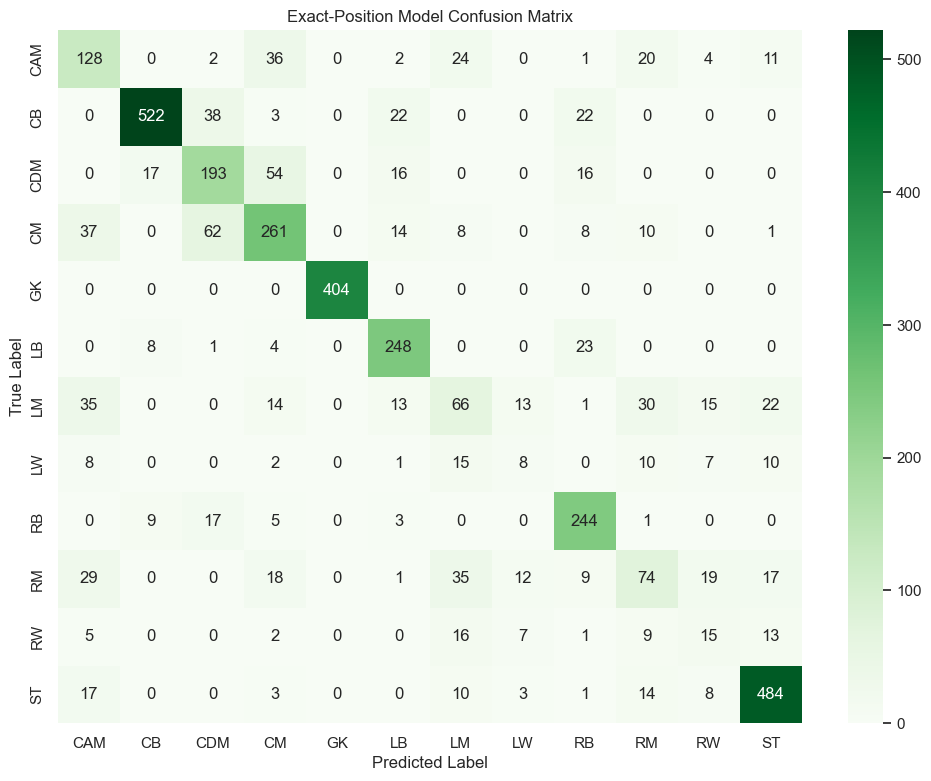

In [17]:
position_labels = position_metrics['labels']
position_confusion = pd.DataFrame(
    position_metrics['confusion_matrix'],
    index=position_labels,
    columns=position_labels,
)

plt.figure(figsize=(12, 9))
sns.heatmap(position_confusion, annot=True, fmt='d', cmap='Greens')
plt.title('Exact-Position Model Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


In [18]:
# Re-evaluate the saved artifacts to confirm reproducibility
role_eval = evaluate_saved_model('role', ROLE_ARTIFACTS_DIR)
position_eval = evaluate_saved_model('position', POSITION_ARTIFACTS_DIR)

pd.DataFrame([
    {'task': 'role', 'accuracy': role_eval['accuracy'], 'macro_f1': role_eval['macro_f1']},
    {'task': 'position', 'accuracy': position_eval['accuracy'], 'macro_f1': position_eval['macro_f1'], 'top_3_accuracy': position_eval['top_3_accuracy']},
])


,task,accuracy,macro_f1,top_3_accuracy
0,role,0.900028,0.912434,NaN
1,position,0.737121,0.610263,0.923141


## Notes

- Saved notebook artifacts are written under `artifacts/notebook/`.
- The reusable Python package is still present, but this notebook is now the main cell-by-cell interface for Jupyter Lab.
- If you want faster experimentation, reduce `ROLE_SEARCH_ITERATIONS` or `POSITION_SEARCH_ITERATIONS` before training.
